# Cifar100 Classification using **Convolutional Neural Networks**

## Imports

Import the required libraries for loading the CIFAR-100 dataset, building the CNN model, training it, and visualizing the results.

In [1]:
import numpy as np
from tensorflow import keras
import matplotlib.pyplot as plt
from keras.optimizers import Adam
from keras.models import Sequential
from keras.datasets import cifar100
from keras.losses import SparseCategoricalCrossentropy
from keras.layers import Conv2D, MaxPooling2D, GlobalAveragePooling2D, Dense, Dropout, Softmax

### Dataset Loading
Loads the CIFAR-100 dataset. Using `label_mode='fine'` ensures we target the 100 distinct object classes.


In [2]:
(X_train, y_train), (X_test, y_test) = cifar100.load_data(label_mode= 'fine')

169001437/169001437 ━━━━━━━━━━━━━━━━━━━━ 2589s 15us/step


## Dataset Summary
| Set | Samples | Image Shape | Label Shape |
| :--- | :--- | :--- | :--- |
| **Train** | 50,000 | (32, 32, 3) | (50000, 1) |
| **Test** | 10,000 | (32, 32, 3) | (10000, 1) |

In [3]:
print(f'X_train shape: {X_train.shape}\nX_test: {X_test.shape}\ny_train: {y_train.shape}\ny_test: {y_test.shape}')

X_train shape: (50000, 32, 32, 3)
X_test: (10000, 32, 32, 3)
y_train: (50000, 1)
y_test: (10000, 1)


## Label Shape Update
The target labels were squeezed from shape `(N, 1)` to `(N,)` for compatibility with model training and evaluation.


In [4]:
y_train = np.squeeze(y_train)
y_test = np.squeeze(y_test)
print(f'y_train new shape: {y_train.shape}\ny_test new shape: {y_test.shape}')

y_train new shape: (50000,)
y_test new shape: (10000,)


In [5]:
fine_labels = [
    'apple', 'aquarium_fish', 'baby', 'bear', 'beaver', 'bed', 'bee',
    'beetle', 'bicycle', 'bottle', 'bowl', 'boy', 'bridge', 'bus',
    'butterfly', 'camel', 'can', 'castle', 'caterpillar', 'cattle',
    'chair', 'chimpanzee', 'clock', 'cloud', 'cockroach', 'couch',
    'crab', 'crocodile', 'cup', 'dinosaur', 'dolphin', 'elephant',
    'flatfish', 'forest', 'fox', 'girl', 'hamster', 'house', 'kangaroo',
    'keyboard', 'lamp', 'lawn_mower', 'leopard', 'lion', 'lizard',
    'lobster', 'man', 'maple_tree', 'motorcycle', 'mountain', 'mouse',
    'mushroom', 'oak_tree', 'orange', 'orchid', 'otter', 'palm_tree',
    'pear', 'pickup_truck', 'pine_tree', 'plain', 'plate', 'poppy',
    'porcupine', 'possum', 'rabbit', 'raccoon', 'ray', 'road',
    'rocket', 'rose', 'sea', 'seal', 'shark', 'shrew', 'skunk',
    'skyscraper', 'snail', 'snake', 'spider', 'squirrel', 'streetcar',
    'sunflower', 'sweet_pepper', 'table', 'tank', 'telephone',
    'television', 'tiger', 'tractor', 'train', 'trout', 'tulip',
    'turtle', 'wardrobe', 'whale', 'willow_tree', 'wolf', 'woman', 'worm'
]

## Visualize a CIFAR-100 Image

The `fine_labels` list maps each numeric label to its corresponding class name.  
A selected training image is displayed with its class label.


Enter a image number: 1502


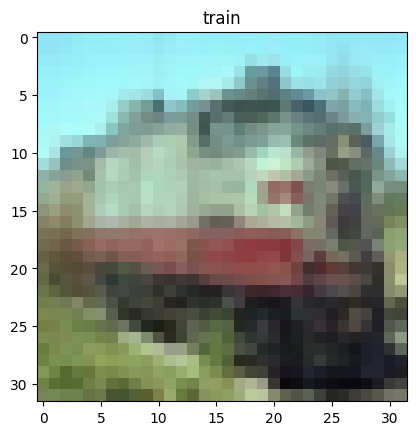

In [14]:
i = int(input('Enter a image number: '))
plt.imshow(X_train[i])
plt.title(fine_labels[y_train[i]]);
plt.savefig(f'{fine_labels[y_train[i]]}_image.png')

## Data Normalization
Pixel values are converted to `float32` and scaled from `[0, 255]` to `[0.0, 1.0]` to accelerate model convergence and improve numerical stability during training.


In [15]:
X_train_norm = X_train.astype('float32') / 255.0
X_test_norm = X_test.astype('float32') / 255.0